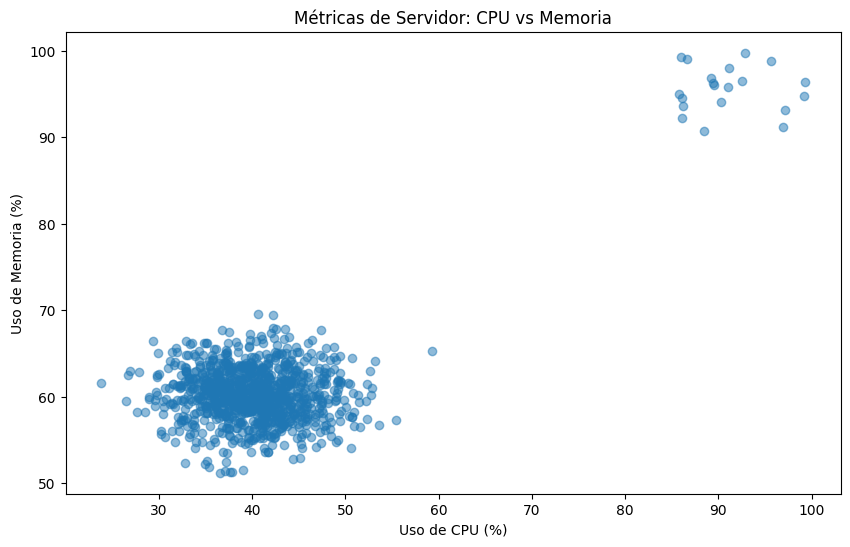

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Simular métricas normales de un servidor (CPU y Memoria)
np.random.seed(42)
n_puntos = 1000
cpu_normal = np.random.normal(loc=40, scale=5, size=n_puntos) # 40% de uso promedio
mem_normal = np.random.normal(loc=60, scale=3, size=n_puntos) # 60% de uso promedio

# 2. Inyectar "Anomalías" (Picos extraños: posibles fallas o ataques)
cpu_anomalo = np.random.uniform(low=85, high=100, size=20)
mem_anomalo = np.random.uniform(low=90, high=100, size=20)

# Combinar todo
cpu = np.concatenate([cpu_normal, cpu_anomalo])
mem = np.concatenate([mem_normal, mem_anomalo])

df_server = pd.DataFrame({'cpu_uso': cpu, 'memoria_uso': mem})

# Visualización inicial
plt.figure(figsize=(10, 6))
plt.scatter(df_server['cpu_uso'], df_server['memoria_uso'], alpha=0.5)
plt.title('Métricas de Servidor: CPU vs Memoria')
plt.xlabel('Uso de CPU (%)')
plt.ylabel('Uso de Memoria (%)')
plt.show()

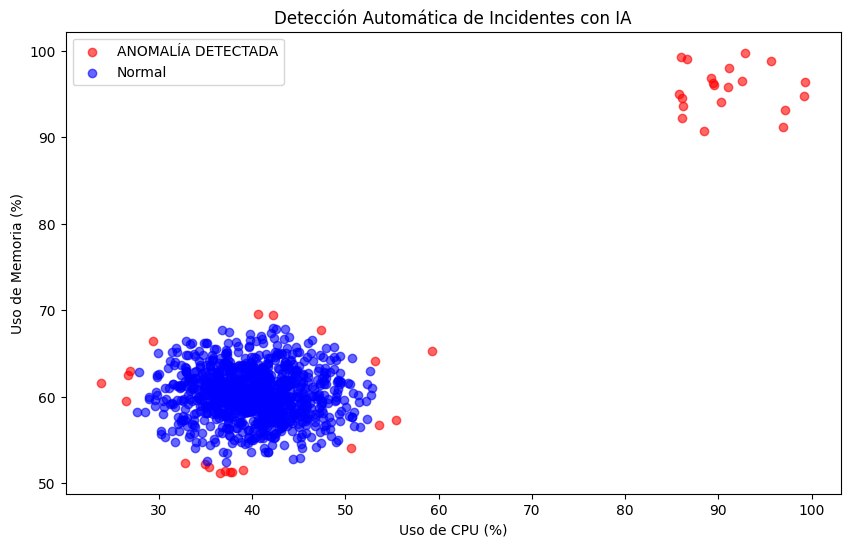

In [3]:
# 1. Configurar el modelo
# contamination=0.04 significa que esperamos que un 4% de los datos sean anomalías
modelo_ia = IsolationForest(contamination=0.04, random_state=42)

# 2. Entrenar (la IA aprende qué es lo "normal")
df_server['anomalia'] = modelo_ia.fit_predict(df_server[['cpu_uso', 'memoria_uso']])

# Explicación del resultado:
#  1 = Normal
# -1 = Anomalía (Peligro)

# 3. Graficar los resultados con colores
plt.figure(figsize=(10, 6))
colores = {1: 'blue', -1: 'red'}

for tipo, grupo in df_server.groupby('anomalia'):
    plt.scatter(
        grupo['cpu_uso'],
        grupo['memoria_uso'],
        c=colores[tipo],
        label='Normal' if tipo == 1 else 'ANOMALÍA DETECTADA',
        alpha=0.6
    )

plt.title('Detección Automática de Incidentes con IA')
plt.xlabel('Uso de CPU (%)')
plt.ylabel('Uso de Memoria (%)')
plt.legend()
plt.show()